In [79]:
import seaborn
import pandas 
import base
import observer
import attrib
import stores
import numpy
import geopandas
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
from datetime import datetime
import h5py
from datetime import datetime, timedelta
from xlsxwriter import Workbook

In [80]:
#Input the local path to the datastore/hdf5 file of interest
#data_store_path = "E:\\Bayer\\bay.18\\models\\xKnowRes_20240315\\run\\TestRun_xKnowRes\\mcs\\X3WD9SKFALFH0YPN74\\store" 
#data_store_path = "E:\\Bayer\\bay.18\\models\\xKnowRes230822\\run\\TestRun_xKnowRes\\mcs\\X3UDQO3DQEVSMR85MU\\store" 
#data_store_path = "E:\\Bayer\\bay.18\\models\\ch_run_20240327\\"   
data_store_path = "E:\\Bayer\\git_all_repos\\xKnowRes\\xKnowRes_main2\\run\\TestRun1\\mcs\\X3D4T2R8C4C2G2YQG7\\store"


#Define path for output folder on local machine
output_folder = "f:\\xknowres_example_plots_scatter\\"



# Select an output file format for the data
output_format = "none"  # ".xlsx"  or  ".csv" or  "none"

# Would you like the raw or summarized datasets?  (Note: summarized data significantly smaller, all fields merged into single value per day per parameter)   
        # summarized = currently set up for calculating the 5th, 50th, and 95th centiles of all fields in the scenario
        # raw = includes each daily value for each field as a row in the table, no statistics calculated
output_tables = "summarized"  # "summarized"  or  "raw"

# Would you like to include the weather data? 
weather_output = "yes"  # "yes"  or  "no"

Names of datasets to select from:
"Dpu/ConcentrationInFruits"
"Dpu/ConcentrationInStems"
"Dpu/ConcentrationInLeaves"
"Dpu/ConcentrationInRoots"
"Pearl/AmaUptPro" 

In [81]:
### Comment/uncomment the variables you would like to plot or create a csv of

datasets_for_pairgrid1 = ["Dpu/ConcentrationInFruits", "Dpu/ConcentrationInStems", "Dpu/ConcentrationInLeaves", "Dpu/ConcentrationInRoots", "Pearl/AmaSysPro"]
datasets_for_pairgrid2 = ["Soil/SiltContent", "Soil/SandContent", "Soil/ClayContent", "Dpu/ConcentrationInFruits"]
#datasets_for_pairgrid3 = ["Dpu/ConcentrationInFruits", "Dpu/ConcentrationInStems", "Dpu/ConcentrationInLeaves", "Dpu/ConcentrationInRoots", "Pearl/AmaUptPro"]

#weather_var = "Weather/TEMPERATURE_AVG" # can set to "Weather/PRECIPITATION" or "Weather/TEMPERATURE_AVG"




#########################################################################################################################################
### Do not change these options yet, functionality not prepared


###To plot an individual field, select based on "field_idx"
#single_field_idx = "12"



########################
###      PLOT 1      ###
########################

#plot1_x = "Time"  # Can set as "Time" or any of the other datasets selected above

###Make sure selected variables on single axis have compatible units!
#plot1_y = ["Dpu/ConcentrationInFruits", "Dpu/ConcentrationInStems", "Dpu/ConcentrationInLeaves", "Dpu/ConcentrationInRoots"]  # Can list 1 or more of the datasets selected above


In [82]:
def subdata_name(input_string):
    parts = input_string.split('/')
    if len(parts) > 1:
        return parts[1]
    else:
        return input_string
    
def group_name(input_string):
    parts = input_string.split('/')
    if len(parts) > 1:
        return parts[0]
    else:
        return input_string

In [83]:
dataset_names = ["Dpu/ConcentrationInFruits", "Dpu/ConcentrationInStems", "Dpu/ConcentrationInLeaves", "Dpu/ConcentrationInRoots", "Pearl/AmaUptPro", "Soil/SiltContent", "Soil/SandContent", "Soil/ClayContent", "Soil/LenDisLiq"]

In [84]:
def get_units_for_datasets(hdf5_file, dataset_names):
    units_dict = {name: None for name in dataset_names}

    def check_and_store_units(hdf5_group, parent_group=''):
        nonlocal units_dict
        for key in hdf5_group.keys():
            if isinstance(hdf5_group[key], h5py.Group):
                check_and_store_units(hdf5_group[key], f"{parent_group}/{key}")
            else:
                dataset_path = f"{parent_group}/{key}"
                for name in dataset_names:
                    if dataset_path.endswith(name):
                        dataset = hdf5_group[key]
                        if 'unit' in dataset.attrs:
                            unit = dataset.attrs['unit']
                            scale = dataset.attrs.get('scales', None)  # Get the 'scales' attribute
                            units_dict[name] = (unit, scale)

    check_and_store_units(hdf5_file)
    return units_dict


arrdat_path = data_store_path+"\\arr.dat"

with h5py.File(arrdat_path, 'r') as hdf5_file:
    units_dict = get_units_for_datasets(hdf5_file, dataset_names)

print(units_dict)

{'Dpu/ConcentrationInFruits': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Dpu/ConcentrationInStems': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Dpu/ConcentrationInLeaves': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Dpu/ConcentrationInRoots': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Pearl/AmaUptPro': ('kg/m²', array(['space/base_geometry', 'time/day'], dtype=object)), 'Soil/SiltContent': ('1', array(['space/base_geometry', 'other/soil_horizon'], dtype=object)), 'Soil/SandContent': ('1', array(['space/base_geometry', 'other/soil_horizon'], dtype=object)), 'Soil/ClayContent': ('1', array(['space/base_geometry', 'other/soil_horizon'], dtype=object)), 'Soil/LenDisLiq': ('m', array(['space/base_geometry', 'other/soil_horizon'], dtype=object))}


In [85]:
# Get the names of variables defined at the top of the code
top_variables = [value for name, value in locals().items() if isinstance(value, str)]

# Filter the units_dict based on the top variable names
filtered_units = {key: value for key, value in units_dict.items() if key in top_variables}

print(top_variables)
print(filtered_units)

['__main__', 'Automatically created module for IPython interactive environment', '', '', 'c:\\Users\\JillianLaRoe\\Desktop\\bay18_map_alter\\LandscapeModelCoremaster\\chart_example_scatter.ipynb', 'def get_units_for_datasets(hdf5_file, dataset_names):\n    units_dict = {name: None for name in dataset_names}\n\n    def check_and_store_units(hdf5_group, parent_group=\'\'):\n        nonlocal units_dict\n        for key in hdf5_group.keys():\n            if isinstance(hdf5_group[key], h5py.Group):\n                check_and_store_units(hdf5_group[key], f"{parent_group}/{key}")\n            else:\n                dataset_path = f"{parent_group}/{key}"\n                for name in dataset_names:\n                    if dataset_path.endswith(name):\n                        dataset = hdf5_group[key]\n                        if \'unit\' in dataset.attrs:\n                            unit = dataset.attrs[\'unit\']\n                            scale = dataset.attrs.get(\'scales\', None)  # Get th

In [86]:
# Get the names of variables defined at the top of the code
top_variables = [name for name, value in locals().items() if isinstance(value, list) and name.startswith("datasets_for_pairgrid")]

# Create a dictionary to store filtered units for each dataset
filtered_units_dict = {}

# Filter the units_dict for each dataset separately
for variable_name in top_variables:
    datasets = locals()[variable_name]
    filtered_units = {key: value for key, value in units_dict.items() if key in datasets}
    filtered_units_dict[variable_name] = filtered_units

# Print filtered units for each dataset
for variable_name, filtered_units in filtered_units_dict.items():
    print(f"Filtered units for {variable_name}:")
    print(filtered_units)

Filtered units for datasets_for_pairgrid1:
{'Dpu/ConcentrationInFruits': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Dpu/ConcentrationInStems': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Dpu/ConcentrationInLeaves': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Dpu/ConcentrationInRoots': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object))}
Filtered units for datasets_for_pairgrid2:
{'Dpu/ConcentrationInFruits': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Soil/SiltContent': ('1', array(['space/base_geometry', 'other/soil_horizon'], dtype=object)), 'Soil/SandContent': ('1', array(['space/base_geometry', 'other/soil_horizon'], dtype=object)), 'Soil/ClayContent': ('1', array(['space/base_geometry', 'other/soil_horizon'], dtype=object))}


In [87]:
dataset_dict = {key: (value[0], list(value[1])) for dataset, units in filtered_units_dict.items() for key, value in units.items()}
dataset_dict = {key: (value[0], ', '.join(value[1])) for key, value in dataset_dict.items()}


for key, value in dataset_dict.items():
    print(f"Key: {key}")
    print(f"Value: {value}")

Key: Dpu/ConcentrationInFruits
Value: ('mg/kg', 'space/base_geometry, time/day')
Key: Dpu/ConcentrationInStems
Value: ('mg/kg', 'space/base_geometry, time/day')
Key: Dpu/ConcentrationInLeaves
Value: ('mg/kg', 'space/base_geometry, time/day')
Key: Dpu/ConcentrationInRoots
Value: ('mg/kg', 'space/base_geometry, time/day')
Key: Soil/SiltContent
Value: ('1', 'space/base_geometry, other/soil_horizon')
Key: Soil/SandContent
Value: ('1', 'space/base_geometry, other/soil_horizon')
Key: Soil/ClayContent
Value: ('1', 'space/base_geometry, other/soil_horizon')


In [88]:
# Initialize an empty list to store datasets
list_of_datasets = []

for key, (first_value, second_value) in dataset_dict.items():
    dataset = base.Input(
        subdata_name(key),
        (attrib.Class(numpy.ndarray), attrib.Unit(first_value), attrib.Scales(second_value)),
        observer.ConsoleObserver(print_output=True),
        base.Output(
            key,
            stores.X3dfStore(data_store_path, mode="r")
        )
    ).read()
    
    list_of_datasets.append(dataset)

NOTE  Input ConcentrationInFruits is missing a detailed description

OK    ConcentrationInFruits:ClassChecker:GetValues

      Values are of type <class 'numpy.ndarray'>

OK    ConcentrationInFruits:UnitChecker:GetValues

      Values have unit mg/kg

OK    ConcentrationInFruits:ScalesChecker:GetValues

      Values have scales space/base_geometry, time/day

NOTE  Input ConcentrationInStems is missing a detailed description

OK    ConcentrationInStems:ClassChecker:GetValues

      Values are of type <class 'numpy.ndarray'>

OK    ConcentrationInStems:UnitChecker:GetValues

      Values have unit mg/kg

OK    ConcentrationInStems:ScalesChecker:GetValues

      Values have scales space/base_geometry, time/day

NOTE  Input ConcentrationInLeaves is missing a detailed description

OK    ConcentrationInLeaves:ClassChecker:GetValues

      Values are of type <class 'numpy.ndarray'>

OK    ConcentrationInLeaves:UnitChecker:GetValues

      Values have unit mg/kg

OK    ConcentrationInLeaves:Sc

In [89]:
hdf5_dataset_1 = list_of_datasets[1]

In [90]:
dfs = []


# Iterate through each dataset in list_of_datasets
for dataset, (key, _) in zip(list_of_datasets, dataset_dict.items()):
    # Create DataFrame for the current dataset
    df = pandas.DataFrame(
        numpy.c_[
            numpy.argwhere(dataset.values > 0),
            dataset.values[dataset.values > 0]
            
            
            
            ### keeping this incase it is of interest to return all values instead of filtering
            #numpy.argwhere(numpy.ones_like(datasets_of_interest.values)),             
            #datasets_of_interest.values.flatten()
        ],
        columns=("field_idx", "time_idx", subdata_name(key))
    )
    
    # Append the DataFrame to dfs
    dfs.append(df)
    
# Merge all DataFrames on "field_idx" and "time_idx"
merged_df = pandas.merge(dfs[0], dfs[1], on=["field_idx", "time_idx"], how="outer")

for df in dfs[2:]:
    merged_df = pandas.merge(merged_df, df, on=["field_idx", "time_idx"], how="outer")

merged_df["date"] = pandas.to_datetime(hdf5_dataset_1.offsets[1]) + pandas.to_timedelta(merged_df["time_idx"], unit="D")
merged_df["date"] = merged_df["date"].dt.strftime("%Y-%m-%d")

merged_df = merged_df.sort_values(by=["date", "field_idx"], ascending=[True, True])

print(merged_df)

       field_idx  time_idx  ConcentrationInFruits  ConcentrationInStems  \
46563        0.0       0.0                    NaN                   NaN   
46566        1.0       0.0                    NaN                   NaN   
46569        2.0       0.0                    NaN                   NaN   
46575        3.0       0.0                    NaN                   NaN   
46579        4.0       0.0                    NaN                   NaN   
...          ...       ...                    ...                   ...   
43934       47.0    1460.0                    NaN              0.001333   
44591       48.0    1460.0                    NaN              0.004278   
45248       49.0    1460.0                    NaN              0.003541   
45901       50.0    1460.0                    NaN              0.004111   
46552       51.0    1460.0                    NaN              0.000813   

       ConcentrationInLeaves  ConcentrationInRoots  SiltContent  SandContent  \
46563              

In [91]:
column_names = merged_df.columns.tolist()
print(column_names)

['field_idx', 'time_idx', 'ConcentrationInFruits', 'ConcentrationInStems', 'ConcentrationInLeaves', 'ConcentrationInRoots', 'SiltContent', 'SandContent', 'ClayContent', 'date']


In [92]:
# Filter columns for pairgrid1
pairgrid1_columns = ['field_idx', 'time_idx', 'date'] + [subdata_name(col) for col in datasets_for_pairgrid1 if subdata_name(col) in merged_df.columns]
pairgrid1 = merged_df[pairgrid1_columns]

# Filter columns for pairgrid2
pairgrid2_columns = ['field_idx', 'time_idx', 'date'] + [subdata_name(col) for col in datasets_for_pairgrid2 if subdata_name(col) in merged_df.columns]
pairgrid2 = merged_df[pairgrid2_columns]

# Display the resulting dataframes
print("pairgrid1:")
print(pairgrid1)

print("\npairgrid2:")
print(pairgrid2)

pairgrid1:
       field_idx  time_idx        date  ConcentrationInFruits  \
46563        0.0       0.0  2013-01-01                    NaN   
46566        1.0       0.0  2013-01-01                    NaN   
46569        2.0       0.0  2013-01-01                    NaN   
46575        3.0       0.0  2013-01-01                    NaN   
46579        4.0       0.0  2013-01-01                    NaN   
...          ...       ...         ...                    ...   
43934       47.0    1460.0  2016-12-31                    NaN   
44591       48.0    1460.0  2016-12-31                    NaN   
45248       49.0    1460.0  2016-12-31                    NaN   
45901       50.0    1460.0  2016-12-31                    NaN   
46552       51.0    1460.0  2016-12-31                    NaN   

       ConcentrationInStems  ConcentrationInLeaves  ConcentrationInRoots  
46563                   NaN                    NaN                   NaN  
46566                   NaN                    NaN        

In [93]:
nan_rows1 = pairgrid1.drop(columns=['field_idx', 'time_idx', 'date']).isna().all(axis=1)

# Exclude rows where all non-essential columns are NaN
pairgrid1_filtered = pairgrid1[~nan_rows1]

# Display the resulting dataframe
print("pairgrid1 after filtering:")
print(pairgrid1_filtered)


nan_rows2 = pairgrid2.drop(columns=['field_idx', 'time_idx', 'date']).isna().all(axis=1)

# Exclude rows where all non-essential columns are NaN
pairgrid2_filtered = pairgrid2[~nan_rows2]

# Display the resulting dataframe
print("pairgrid2 after filtering:")
print(pairgrid2_filtered)

pairgrid1 after filtering:
       field_idx  time_idx        date  ConcentrationInFruits  \
13762        0.0     305.0  2013-11-02                    NaN   
14404        1.0     305.0  2013-11-02                    NaN   
15046        2.0     305.0  2013-11-02                    NaN   
16326        4.0     305.0  2013-11-02                    NaN   
18241        7.0     305.0  2013-11-02                    NaN   
...          ...       ...         ...                    ...   
43934       47.0    1460.0  2016-12-31                    NaN   
44591       48.0    1460.0  2016-12-31                    NaN   
45248       49.0    1460.0  2016-12-31                    NaN   
45901       50.0    1460.0  2016-12-31                    NaN   
46552       51.0    1460.0  2016-12-31                    NaN   

       ConcentrationInStems  ConcentrationInLeaves  ConcentrationInRoots  
13762          8.764795e-04           3.592937e-04          1.632961e-03  
14404          1.912454e-03           7.81

In [94]:
columns_to_fill1 = pairgrid1_filtered.columns.difference(['field_idx', 'time_idx', 'date'])

pairgrid1_filtered.loc[:, columns_to_fill1] = pairgrid1_filtered.loc[:, columns_to_fill1].fillna(0)

# Display the resulting dataframe
print("pairgrid1_filtered after replacing NaN with 0:")
print(pairgrid1_filtered)



columns_to_fill2 = pairgrid2_filtered.columns.difference(['field_idx', 'time_idx', 'date'])

pairgrid2_filtered.loc[:, columns_to_fill2] = pairgrid2_filtered.loc[:, columns_to_fill2].fillna(0)

# Display the resulting dataframe
print("pairgrid2_filtered after replacing NaN with 0:")
print(pairgrid2_filtered)

pairgrid1_filtered after replacing NaN with 0:
       field_idx  time_idx        date  ConcentrationInFruits  \
13762        0.0     305.0  2013-11-02                    0.0   
14404        1.0     305.0  2013-11-02                    0.0   
15046        2.0     305.0  2013-11-02                    0.0   
16326        4.0     305.0  2013-11-02                    0.0   
18241        7.0     305.0  2013-11-02                    0.0   
...          ...       ...         ...                    ...   
43934       47.0    1460.0  2016-12-31                    0.0   
44591       48.0    1460.0  2016-12-31                    0.0   
45248       49.0    1460.0  2016-12-31                    0.0   
45901       50.0    1460.0  2016-12-31                    0.0   
46552       51.0    1460.0  2016-12-31                    0.0   

       ConcentrationInStems  ConcentrationInLeaves  ConcentrationInRoots  
13762          8.764795e-04           3.592937e-04          1.632961e-03  
14404          1.91245

##      SEABORN PAIRGRID PLOT 1 (using datasets_for_pairgrid1) 

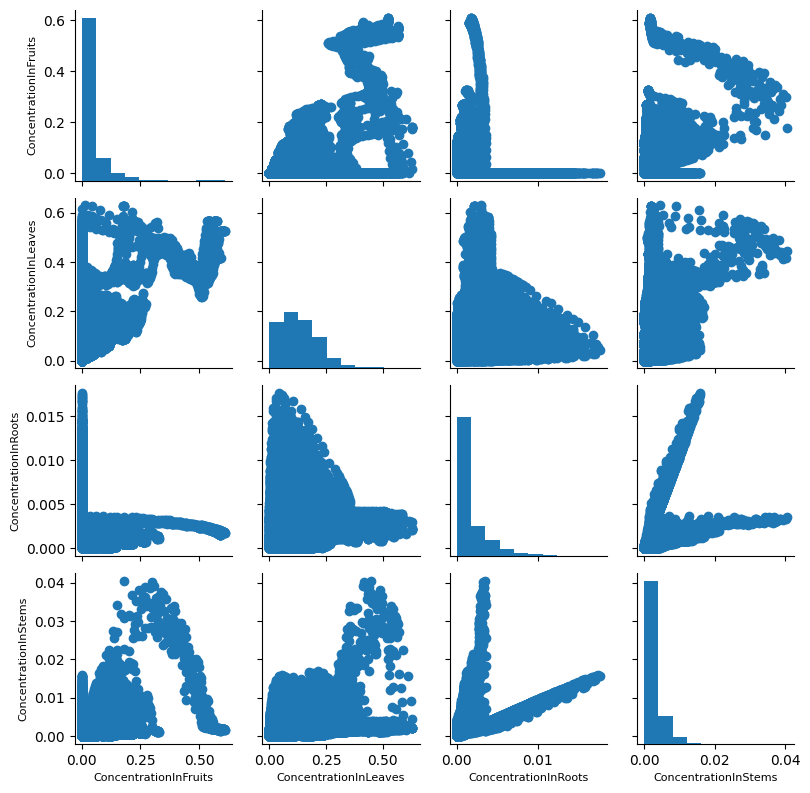

In [95]:
# Select columns for PairGrid
columns_for_plot1 = pairgrid1_filtered.columns.difference(['field_idx', 'time_idx', 'date'])

# Create PairGrid
g = seaborn.PairGrid(pairgrid1_filtered, vars=columns_for_plot1)

# Scatter plot, histogram on diagonal
g = g.map_diag(plt.hist)
g = g.map_offdiag(plt.scatter)

# Set plot size
g.fig.set_size_inches(8, 8)  

# Decrease the label size
for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=8)
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)

# Adding titles
for i, (var1, var2) in enumerate(zip(columns_for_plot1[:0], columns_for_plot1[0:])):
    g.axes[i, 0].set_ylabel(var2)
    g.axes[-1, i].set_xlabel(var1)

plt.show()

# SEABORN PAIRGRID PLOT 2 (using datasets_for_pairgrid2) 

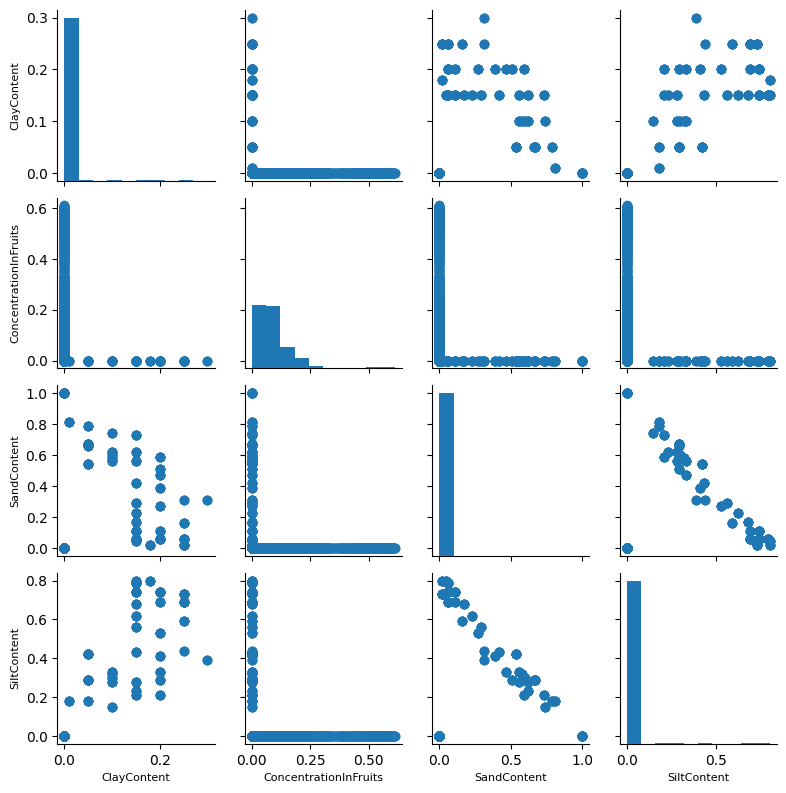

In [96]:
# Select columns for PairGrid
columns_for_plot2 = pairgrid2_filtered.columns.difference(['field_idx', 'time_idx', 'date'])

# Create PairGrid
g = seaborn.PairGrid(pairgrid2_filtered, vars=columns_for_plot2)

# Scatter plot, histogram on diagonal
g = g.map_diag(plt.hist)
g = g.map_offdiag(plt.scatter)

# Set plot size
g.fig.set_size_inches(8, 8)  

# Decrease the label size
for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=8)
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)

# Adding titles
for i, (var1, var2) in enumerate(zip(columns_for_plot2[:0], columns_for_plot2[0:])):
    g.axes[i, 0].set_ylabel(var2)
    g.axes[-1, i].set_xlabel(var1)

plt.show()